## Loading the Modules

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the Dataset

In [ ]:
path='/content/drive/MyDrive/Almabetter/EDA Paisabazaar/dataset.csv'
df=pd.read_csv(path)

In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [ ]:
df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.663572,378.0,No,35.104023,24.028477,High_spent_Large_value_payments,479.866228,Poor
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,40.565631,379.0,No,35.104023,24.028477,High_spent_Medium_value_payments,496.651610,Poor
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,33.638208,381.0,No,35.104023,24.028477,Low_spent_Large_value_payments,319.164979,Standard
99999,155629,37932,8,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.192463,382.0,No,35.104023,24.028477,High_spent_Medium_value_payments,393.673696,Poor


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [ ]:
df=df.drop(['ID','Customer_ID','Name','SSN'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int64  
 1   Age                       100000 non-null  float64
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Num_Credit_Card           100000 non-null  float64
 7   Interest_Rate             100000 non-null  float64
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              100000 non-null  object 
 10  Delay_from_due_date       100000 non-null  float64
 11  Num_of_Delayed_Payment    100000 non-null  float64
 12  Changed_Credit_Limit      100000 non-null  float64
 13  Num_Credit_Inquiries      100000 non-null  fl

## Exploratory Data Analysis

#### 1. Does Higher income lead to better Credit score?

<Axes: xlabel='Credit_Score', ylabel='Annual_Income'>

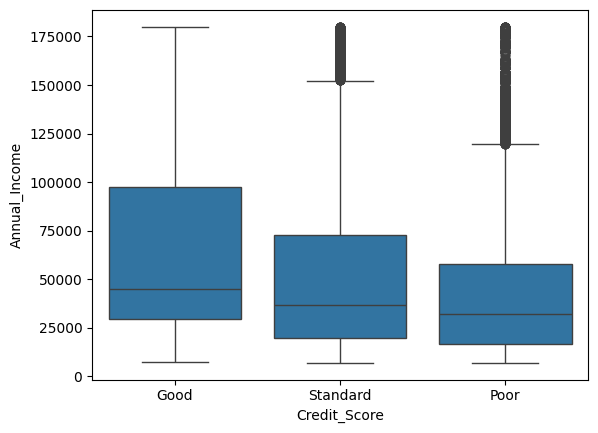

In [ ]:
sns.boxplot(x=df['Credit_Score'],y=df['Annual_Income'])

##### Insights

Customers with Good credit scores generally earn more than customers with Standard or Poor scores, suggesting that higher income positively influences creditworthiness. However, significant overlap between groups indicates that income alone is insufficient to predict credit score and should be combined with behavioral financial indicators.

#### 2. Does debt impact score?

<Axes: xlabel='Credit_Score', ylabel='Outstanding_Debt'>

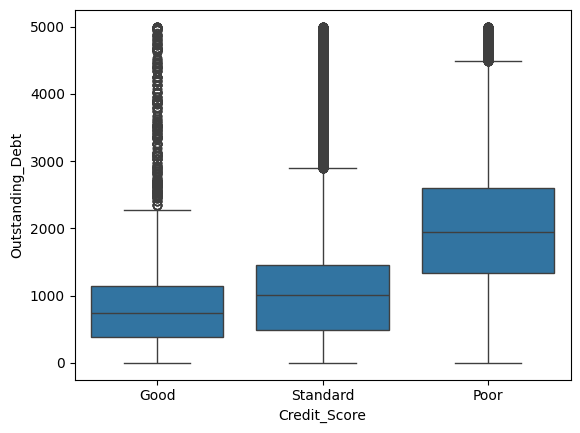

In [ ]:
sns.boxplot(x='Credit_Score',y='Outstanding_Debt',data=df)

##### Insights

Customers with Poor credit scores exhibit substantially higher outstanding debt compared to customers with Good credit scores. The strong upward trend across credit score categories suggests that outstanding debt is a critical factor influencing customer creditworthiness.

#### 3. Does Delayed Payment affect credit score??

<Axes: xlabel='Credit_Score', ylabel='Delay_from_due_date'>

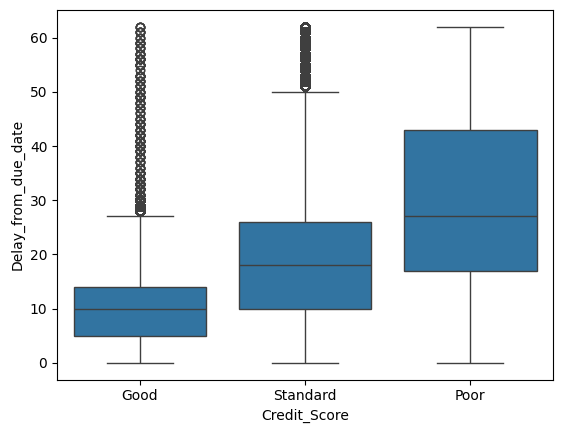

In [ ]:
sns.boxplot(data=df,x='Credit_Score',y='Delay_from_due_date')

##### Insights

Payment delay exhibits a strong negative relationship with credit score. Customers with Poor credit scores consistently demonstrate higher delay periods compared to Good credit score customers, indicating that repayment discipline is a key determinant of creditworthiness.

## Advanced EDA

###Credit Mix vs Credit score

In [ ]:
pd.crosstab(df['Credit_Mix'],df['Credit_Score'],normalize='index')*100

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,1.476775,60.118647,38.404578
Good,48.867825,15.965640,35.166535
Standard,5.734165,21.501483,72.764352


<Axes: xlabel='Credit_Mix', ylabel='count'>

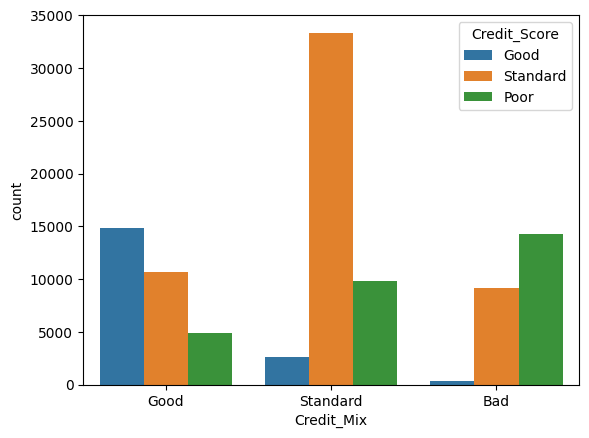

In [ ]:
sns.countplot(data=df,x='Credit_Mix',hue='Credit_Score')

#### Insights

Customers with a Good Credit Mix demonstrate significantly better credit scores, while customers with a Bad Credit Mix are predominantly classified as Poor credit risks. This suggests that maintaining a diversified and balanced credit portfolio positively influences creditworthiness.

### Payment Behaviour vs Credit Score

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'High_spent_Small_value_payments'),
  Text(1, 0, 'Low_spent_Large_value_payments'),
  Text(2, 0, 'Low_spent_Medium_value_payments'),
  Text(3, 0, 'Low_spent_Small_value_payments'),
  Text(4, 0, 'High_spent_Medium_value_payments'),
  Text(5, 0, 'High_spent_Large_value_payments')])

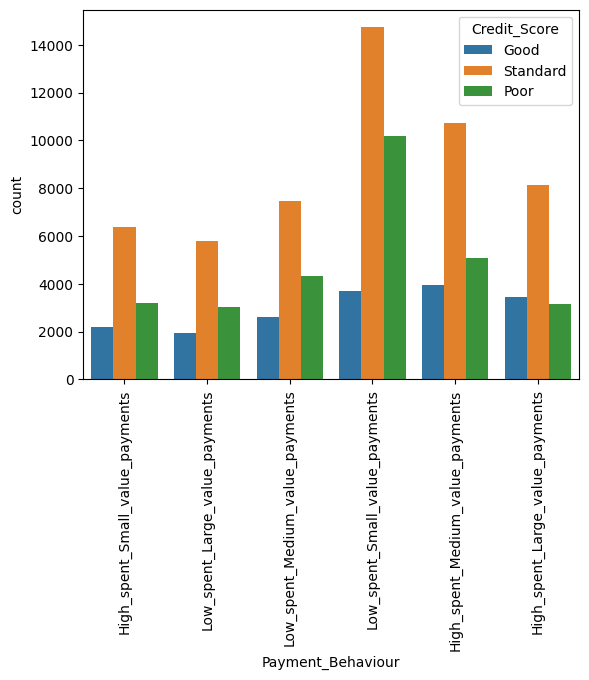

In [ ]:
sns.countplot(data=df,x='Payment_Behaviour',hue='Credit_Score')
plt.xticks(rotation=90)

#### Insights

Spending patterns influence credit scores, but their impact is weaker than debt and repayment behavior. Customers with frequent high-value spending tend to maintain acceptable credit scores when supported by strong repayment discipline and income levels.

###Occupation Analysis

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Scientist'),
  Text(1, 0, 'Teacher'),
  Text(2, 0, 'Engineer'),
  Text(3, 0, 'Entrepreneur'),
  Text(4, 0, 'Developer'),
  Text(5, 0, 'Lawyer'),
  Text(6, 0, 'Media_Manager'),
  Text(7, 0, 'Doctor'),
  Text(8, 0, 'Journalist'),
  Text(9, 0, 'Manager'),
  Text(10, 0, 'Accountant'),
  Text(11, 0, 'Musician'),
  Text(12, 0, 'Mechanic'),
  Text(13, 0, 'Writer'),
  Text(14, 0, 'Architect')])

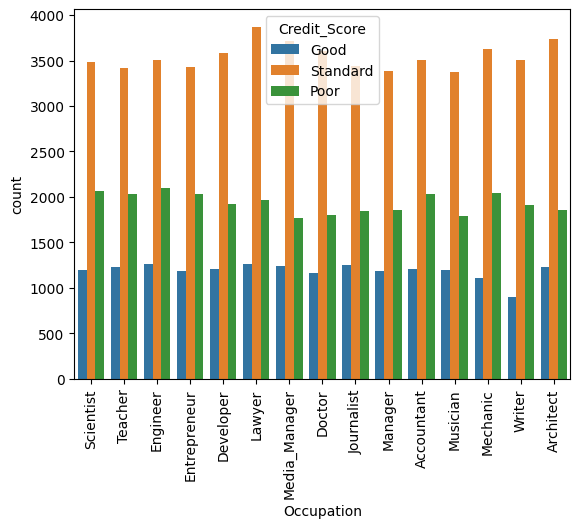

In [ ]:
sns.countplot(data=df,x='Occupation',hue='Credit_Score')
plt.xticks(rotation=90)

#### Insights

Credit score distributions remain relatively consistent across occupations, suggesting that financial behavior plays a much greater role in determining creditworthiness than professional background.

### Correlation Heatmap

<Axes: >

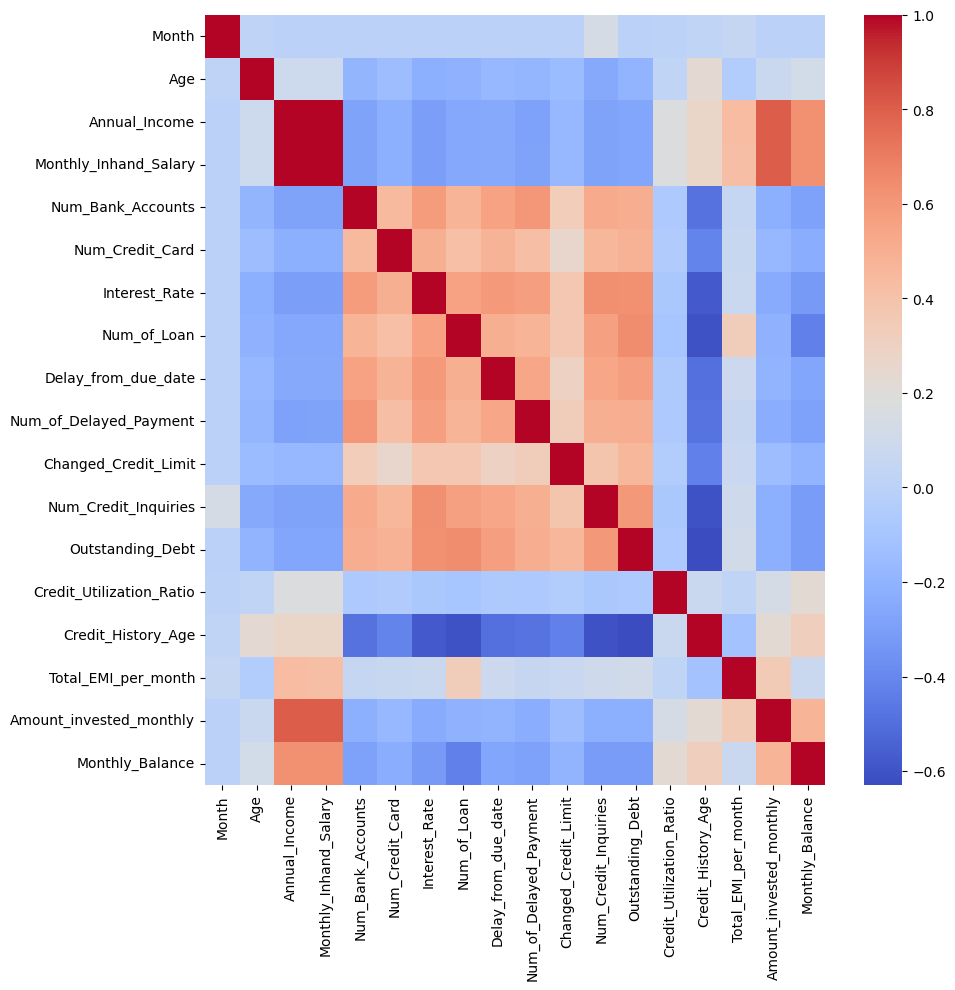

In [ ]:
plt.figure(figsize=(10,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

#### Insights

Strong Positive Correlations
Annual Income ↔ Monthly Inhand Salary

Very strong positive relationship.

Expected because salary contributes directly to annual income.

Annual Income ↔ Amount Invested Monthly

Higher-income customers invest more.

This reflects stronger financial planning behavior.

Monthly Balance ↔ Amount Invested Monthly

Positive correlation.

Customers with healthier balances invest more.

Strong Negative Correlations
Credit History Age ↔ Outstanding Debt

Strong negative relationship.

Customers with longer credit histories generally maintain lower debt burdens.

Credit History Age ↔ Credit Inquiries

Negative correlation.

Experienced borrowers tend to seek fewer new credit products.

Credit History Age ↔ Delayed Payments

Negative correlation.

Older credit histories often indicate better repayment discipline.

Risk Cluster

Notice these variables move together:

Interest Rate
Number of Loans
Delayed Payments
Credit Inquiries
Outstanding Debt

They form a "Risk Group."

When one increases, others often increase as well.

## Feature Engineering

In [ ]:
df_fe=df.copy()

### DTI (Debt-to-income) ratio

In [ ]:
df_fe['Debt_Income_Ratio']=df_fe['Outstanding_Debt'] / df_fe['Annual_Income']

#### EMI Burden Ratio

In [ ]:
df_fe['EMI_Burden_Ratio'] = df_fe['Total_EMI_per_month'] / df_fe['Monthly_Inhand_Salary']

### Credit Exposure

In [ ]:
df_fe['Credit_Exposure'] = df_fe['Num_Credit_Card'] + df_fe['Num_of_Loan']

### Payment Risk Score

In [ ]:
df_fe['Payment_risk'] = df_fe['Delay_from_due_date'] * df_fe['Num_of_Delayed_Payment']

### Inquiry Risk Score

In [ ]:
df_fe['Inquiry_risk'] = df_fe['Num_Credit_Inquiries'] * df_fe['Num_of_Loan']

### Checking new Features

In [ ]:
df_fe.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_Income_Ratio,EMI_Burden_Ratio,Credit_Exposure,Payment_risk,Inquiry_risk
0,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good,0.042376,0.027167,8.0,21.0,16.0
1,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good,0.042376,0.027167,8.0,12.0,16.0
2,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good,0.042376,0.027167,8.0,21.0,16.0
3,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good,0.042376,0.027167,8.0,20.0,16.0
4,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good,0.042376,0.027167,8.0,24.0,16.0


## Data Preprocessing

### Step-1 : Seperate Values and Target

In [ ]:
X=df_fe.drop('Credit_Score',axis=1)
y=df_fe['Credit_Score']

### Step 2 : Encode Target Variable

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()
y=le.fit_transform(y)
print(le.classes_)

['Good' 'Poor' 'Standard']


### Step 3 : Identify Numerical and Categorical Columns

In [ ]:
num_cols=X.select_dtypes(include=['int64','float64']).columns
cat_cols=X.select_dtypes(include='object').columns

In [ ]:
num_cols

Index(['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'Debt_Income_Ratio', 'EMI_Burden_Ratio',
       'Credit_Exposure', 'Payment_risk', 'Inquiry_risk'],
      dtype='object')

In [ ]:
cat_cols

Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')

### Step 4 : Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test =train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42,
    stratify=y)

### Step 5 : Create Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

####Numerical Pipeline

In [ ]:
num_pipeline = Pipeline([
    ('scaler',StandardScaler())
])

#### Categorical Pipeline

In [ ]:
cat_pipeline = Pipeline([
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

#### Combine Pipelines

In [ ]:
preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

#### Transform Data

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Feature Selection

### Method -1  Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/loc

##### View Top Features

In [ ]:
feature_names =(
    preprocessor.get_feature_names_out()
)
mi_df=pd.DataFrame({
    'Feature':feature_names,
    'MI_Score':mi_scores
})

mi_df.sort_values(
    by='MI_Score',
    ascending=False
).head(20)

,Feature,MI_Score
13,num__Credit_Utilization_Ratio,1.002251
17,num__Monthly_Balance,0.996116
3,num__Monthly_Inhand_Salary,0.705856
18,num__Debt_Income_Ratio,0.697723
2,num__Annual_Income,0.696993
16,num__Amount_invested_monthly,0.687454
12,num__Outstanding_Debt,0.685976
19,num__EMI_Burden_Ratio,0.639900
15,num__Total_EMI_per_month,0.638358
6,num__Interest_Rate,0.171834


### Base Line models

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#### Function

In [ ]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):
  model.fit(X_train,y_train)

  pred=model.predict(X_test)

  accuracy=accuracy_score(
      y_test,
      pred,
  )

  recall=recall_score(
      y_test,
      pred,
      average='weighted'
  )

  precision =precision_score(
      y_test,
      pred,
      average='weighted'
  )

  f1=f1_score(
      y_test,
      pred,
      average='weighted'
  )

  return [
      accuracy,
      precision,
      recall,
      f1
  ]


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(
    max_iter=1000
)

lr_result=evaluate_model(
    lr,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

lr_result

[0.749, 0.7511569697194406, 0.749, 0.749693110050856]

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(
    random_state=42
)

dt_result=evaluate_model(
    dt,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

dt_result

[0.76955, 0.7693272119110465, 0.76955, 0.7694217298892383]

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf_result = evaluate_model(
    rf,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

rf_result

[0.82125, 0.8214265628725245, 0.82125, 0.8212756323714242]

### XGBOOST

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    random_state=42
)

xgb_result=evaluate_model(
    xgb,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)

xgb_result

[0.74285, 0.7460734631962601, 0.74285, 0.7432684158635231]

## Model Comparision

In [ ]:
results=pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest','XGBoost'],
    'Accuracy':[lr_result[0],dt_result[0],rf_result[0],xgb_result[0]],
    'Precision':[lr_result[2],dt_result[2],rf_result[2],xgb_result[2]],
    'Recall':[lr_result[1],dt_result[1],rf_result[1],xgb_result[1]],
    'f1':[lr_result[3],dt_result[3],rf_result[3],xgb_result[3]],
    })

results.sort_values(by='f1',ascending=False)

,Model,Accuracy,Precision,Recall,f1
2,Random Forest,0.82125,0.82125,0.821427,0.821276
1,Decision Tree,0.76955,0.76955,0.769327,0.769422
0,Logistic Regression,0.74900,0.74900,0.751157,0.749693
3,XGBoost,0.74285,0.74285,0.746073,0.743268


## Hyper Parameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
param_dist={
    'n_estimators':[200,300,400,500],
    'max_depth':[20,30,40,50,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt'],
    'bootstrap':[True],
}

In [ ]:
rf=RandomForestClassifier(
    random_state=42
)

random_search =RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(
    X_train_processed,
    y_train
)

Fitting 2 folds for each of 10 candidates, totalling 20 fits


RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [20, 30, 40, 50, None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [200, 300, 400, 500]},
                   random_state=42, scoring='f1_weighted', verbose=2)

In [164]:
random_search.best_params_

{'n_estimators': 400,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None,
 'bootstrap': True}

In [165]:
best_rf = random_search.best_estimator_
best_rf.fit(
    X_train_processed,
    y_train
)
pred = best_rf.predict(
    X_test_processed
)

In [166]:
accuracy=accuracy_score(y_test,pred)
precision=precision_score(
    y_test,
    pred,
    average='weighted'
)
recall=recall_score(
    y_test,
    pred,
    average='weighted'
)
f1=f1_score(
    y_test,
    pred,
    average='weighted'
)

In [167]:
print("accuracy :",accuracy)
print('Precision: ',precision)
print('recall: ',recall)
print('f1 score :',f1)

accuracy : 0.8225
Precision:  0.8226903180714226
recall:  0.8225
f1 score : 0.82253383257079


### Feature Importance

In [168]:
best_rf=random_search.best_estimator_
importance=best_rf.feature_importances_

feature_names = preprocessor.get_feature_names_out()
importance_df=pd.DataFrame({
    'Feature':feature_names,
    'Importance':importance
})
top_features=(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    ).head(15)
)
top_features

,Feature,Importance
12,num__Outstanding_Debt,0.053687
6,num__Interest_Rate,0.048824
18,num__Debt_Income_Ratio,0.038285
8,num__Delay_from_due_date,0.035979
6301,cat__Credit_Mix_Standard,0.035886
21,num__Payment_risk,0.035138
14,num__Credit_History_Age,0.034501
10,num__Changed_Credit_Limit,0.033812
5,num__Num_Credit_Card,0.032355
6300,cat__Credit_Mix_Good,0.032231


Detailed Business Insights
1. Outstanding Debt (Most Important Feature)

Importance: 5.37%

Interpretation

Customers with higher outstanding debt are more likely to receive lower credit scores.

This aligns perfectly with your EDA findings.

Business Impact

High debt reduces repayment capacity and increases financial risk.

Recommendation

Customers with rapidly increasing debt should be flagged for risk monitoring.

2. Interest Rate

Importance: 4.88%

Interpretation

Higher-risk customers generally receive loans at higher interest rates.

The model identifies interest rate as a strong indicator of creditworthiness.

Business Impact

Interest rates indirectly reflect customer risk levels.

3. Debt Income Ratio

Importance: 3.83%

Interpretation

This is one of your engineered features.

A higher debt-to-income ratio indicates that a significant portion of income is committed to debt obligations.

Project Highlight

This proves that your feature engineering added business value.

You should definitely mention this in interviews.

4. Delay from Due Date

Importance: 3.60%

Interpretation

Payment delays directly impact credit scores.

Customers with frequent delays exhibit poorer credit behavior.

Validation

Your EDA predicted this would be a strong feature.

The model confirms it.

5. Credit Mix

Importance:

Standard Credit Mix → 3.59%
Good Credit Mix → 3.22%
Interpretation

Customers with a balanced mix of credit products tend to have healthier credit profiles.

Validation

Matches your Credit Mix EDA analysis perfectly.

6. Payment Risk

Importance: 3.51%

Interpretation

This engineered feature combines:

Delay_from_due_date
*
Num_of_Delayed_Payment

This captures repayment discipline better than either feature alone.

Project Highlight

Another engineered feature appearing in Top Features.

Excellent result.

7. Credit History Age

Importance: 3.45%

Interpretation

Customers with longer credit histories generally have more stable financial behavior.

Business Impact

Longer histories provide more evidence of responsible borrowing.

8. Credit Inquiries & Inquiry Risk

Combined Importance:

Inquiry Risk
+
Num Credit Inquiries
=
~6%
Interpretation

Customers frequently applying for new credit products tend to have lower credit scores.

Business Meaning

Repeated inquiries often indicate financial stress or aggressive borrowing.

Validation of EDA Findings

Let's compare:

EDA Prediction	ML Result
Outstanding Debt	✅ Top Feature
Delay From Due Date	✅ Top Feature
Credit Mix	✅ Top Feature
Credit History Age	✅ Top Feature
Credit Inquiries	✅ Top Feature
Debt Income Ratio	✅ Top Feature

This is exactly what we want.

Your EDA successfully identified the drivers of credit score before the model was trained.

Business Recommendations
Recommendation 1

Identify customers with:

High Outstanding Debt
High Debt Income Ratio

and classify them as high-risk customers.

Recommendation 2

Implement automated reminders for customers with:

Increasing Delay from Due Date

to reduce future credit deterioration.

Recommendation 3

Monitor customers with:

High Credit Inquiries
Multiple Loans

as they exhibit elevated financial risk.

Recommendation 4

Encourage customers to maintain:

Balanced Credit Mix
Long Credit History

to improve long-term credit health.

### Confusion Matrix

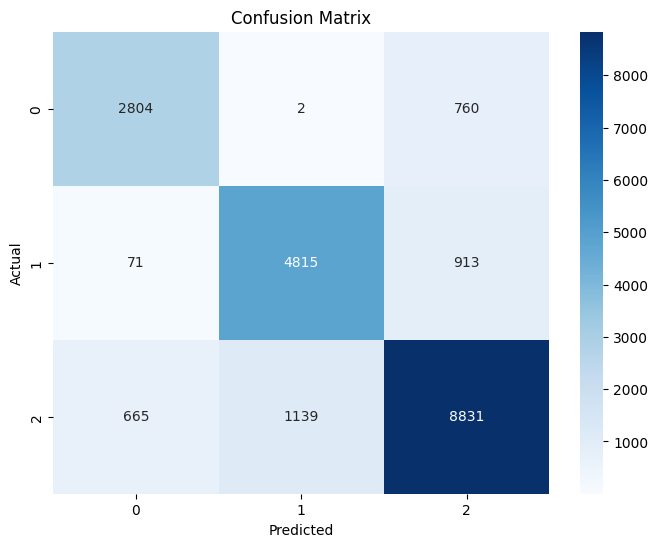

In [171]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel("Actual")

plt.show()

In [172]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79      3566
           1       0.81      0.83      0.82      5799
           2       0.84      0.83      0.84     10635

    accuracy                           0.82     20000
   macro avg       0.81      0.82      0.81     20000
weighted avg       0.82      0.82      0.82     20000

